# Financial Risk Measurement and VaR Backtesting

## Quantitative analysis of SPY market risk

This notebook develops and evaluates several financial risk models using
historical market data for the SPDR S&P 500 ETF Trust (**SPY**).

The analysis includes:

- Historical Value at Risk
- Parametric Value at Risk
- Monte Carlo Value at Risk
- Expected Shortfall
- Rolling risk forecasts
- VaR exceptions
- Kupiec unconditional coverage test
- Christoffersen independence test
- Conditional coverage test
- Comparison and interpretation of risk models

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current_directory = Path.cwd().resolve()

if (current_directory / "src").exists():
    project_root = current_directory
elif (current_directory.parent / "src").exists():
    project_root = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing src."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.backtesting import backtest_value_at_risk
from src.christoffersen import conditional_coverage_test
from src.data_loader import load_market_data
from src.market_backtest import run_market_backtest
from src.rolling_var import calculate_rolling_var_forecasts

plt.style.use("ggplot")

print(f"Python executable: {sys.executable}")
print(f"Project root: {project_root}")
print("Imports completed successfully.")

## 1. Mathematical Foundations

### 1.1 Asset prices

Let \(P_t\) represent the adjusted closing price of an asset on trading
day \(t\).

Adjusted prices account for relevant corporate actions and allow prices
from different dates to be compared consistently.

### 1.2 Simple daily return

The simple daily return is:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

where:

- \(R_t\) is the return on day \(t\);
- \(P_t\) is the price on day \(t\);
- \(P_{t-1}\) is the previous trading day's price.

If the price increases from \$100 to \$102:

$$
R_t = \frac{102}{100} - 1 = 0.02 = 2\%
$$

A positive return represents a gain. A negative return represents a
decrease in the value of the asset.

### 1.3 Monetary loss

Let \(V\) represent the value of the portfolio. The monetary loss is
defined as:

$$
L_t = -V R_t
$$

This sign convention makes losses positive and gains negative.

For a \$1,000,000 portfolio with a return of \(-2\%\):

$$
L_t = -(1{,}000{,}000)(-0.02)
$$

$$
L_t = \$20{,}000
$$

Therefore, a negative return of 2% represents a positive monetary loss
of \$20,000.

## 2. Historical Market Data

The analysis uses adjusted daily closing prices for SPY from January
2021 through December 2025.

The preparation process consists of:

1. Downloading adjusted closing prices.
2. Sorting observations chronologically.
3. Removing missing or non-finite values.
4. Verifying that prices are positive.
5. Calculating simple daily returns.
6. Aligning each return with its trading date.

A collection of \(n\) prices produces \(n-1\) returns because the first
price has no previous observation:

$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

The historical sample will later be divided into:

- an estimation window containing past information;
- an out-of-sample day on which the VaR forecast is evaluated.

This separation prevents the model from using future information.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

current_directory = Path.cwd().resolve()

if (current_directory / "src").is_dir():
    project_root = current_directory
elif (current_directory.parent / "src").is_dir():
    project_root = current_directory.parent
else:
    raise FileNotFoundError(
        "Could not find the project folder containing src."
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.backtesting import backtest_value_at_risk
from src.christoffersen import conditional_coverage_test
from src.data_loader import load_market_data
from src.market_backtest import run_market_backtest
from src.rolling_var import calculate_rolling_var_forecasts

plt.style.use("ggplot")

print(f"Python executable: {sys.executable}")
print(f"Project root: {project_root}")
print("Imports completed successfully.")

Python executable: c:\Users\Admin\Documents\Utech\Proyectos\financial-risk-backtesting-engine\.venv\Scripts\python.exe
Project root: C:\Users\Admin\Documents\Utech\Proyectos\financial-risk-backtesting-engine
Imports completed successfully.


In [6]:
market_data = load_market_data(
    ticker="SPY",
    start_date="2021-01-01",
    end_date="2026-01-01",
)

prices = market_data.prices
returns = market_data.returns

data_summary = pd.DataFrame(
    {
        "Metric": [
            "Ticker",
            "First trading date",
            "Last trading date",
            "Price observations",
            "Return observations",
            "Average daily return",
            "Daily volatility",
            "Worst daily return",
            "Best daily return",
        ],
        "Value": [
            market_data.ticker,
            prices.index.min().date(),
            prices.index.max().date(),
            f"{len(prices):,}",
            f"{len(returns):,}",
            f"{returns.mean():.4%}",
            f"{returns.std(ddof=1):.4%}",
            f"{returns.min():.4%}",
            f"{returns.max():.4%}",
        ],
    }
)

print("Market data loaded successfully.")
data_summary

Market data loaded successfully.


,Metric,Value
0,Ticker,SPY
1,First trading date,2021-01-04
2,Last trading date,2025-12-31
3,Price observations,"1,255"
4,Return observations,"1,254"
5,Average daily return,0.0603%
6,Daily volatility,1.0779%
7,Worst daily return,-5.8543%
8,Best daily return,10.5019%


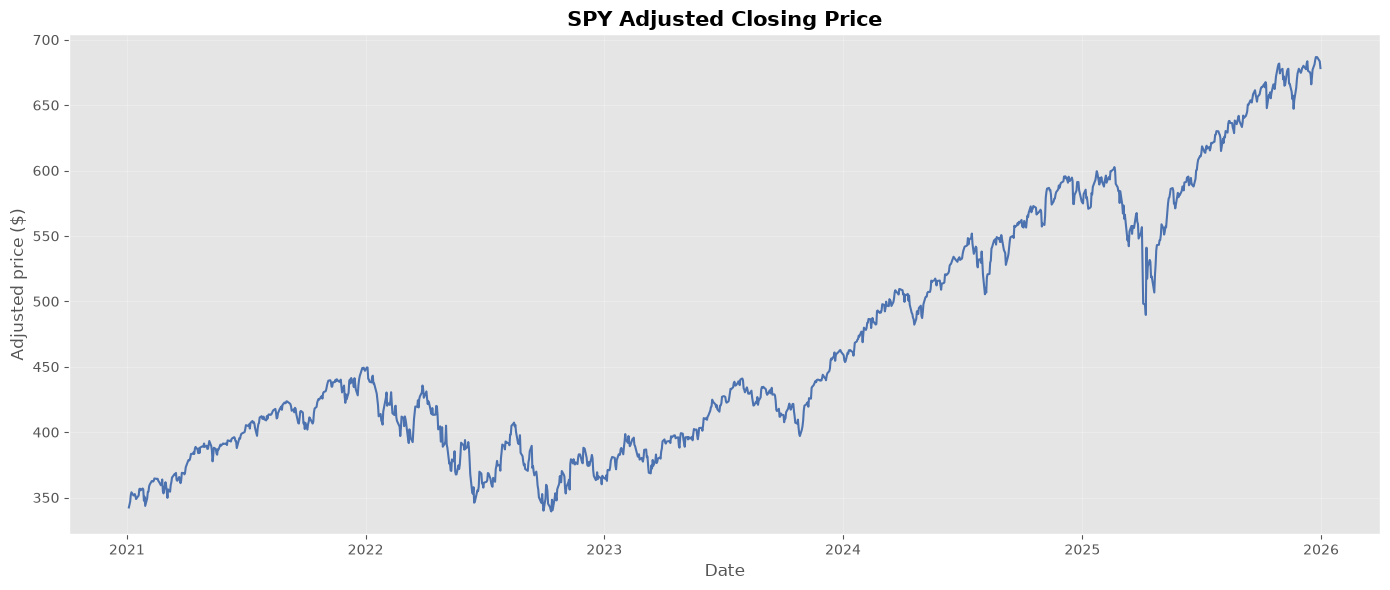

In [7]:
figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.plot(
    prices.index,
    prices.values,
    color="#4C72B0",
    linewidth=1.5,
)

axis.set_title(
    "SPY Adjusted Closing Price",
    fontsize=15,
    fontweight="bold",
)

axis.set_xlabel("Date")
axis.set_ylabel("Adjusted price ($)")
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 3. Historical Value at Risk

### 3.1 Model definition

Historical VaR is a non-parametric risk model. It does not assume that
returns follow a normal distribution or any other theoretical
distribution.

Instead, it uses the empirical distribution of previously observed
losses.

Let the historical returns be:

$$
R_1, R_2, \ldots, R_n
$$

For a portfolio with value \(V\), returns are converted into monetary
losses using:

$$
L_t = -V R_t
$$

The historical VaR at confidence level \(\alpha\) is the empirical
\(\alpha\)-quantile of the loss observations:

$$
\operatorname{VaR}_{\alpha}^{\text{hist}}
=
Q_{\alpha}
\left(
L_1,L_2,\ldots,L_n
\right)
$$

At a 99% confidence level:

$$
\alpha = 0.99
$$

This means that approximately 99% of historical losses are less than or
equal to the VaR threshold, while approximately 1% exceed it.

### 3.2 Historical Expected Shortfall

Historical Expected Shortfall is the average of the losses that exceed
the VaR threshold:

$$
\operatorname{ES}_{\alpha}^{\text{hist}}
=
\frac{
\sum_{t=1}^{n}
L_t
\mathbf{1}
\left(
L_t >
\operatorname{VaR}_{\alpha}^{\text{hist}}
\right)
}{
\sum_{t=1}^{n}
\mathbf{1}
\left(
L_t >
\operatorname{VaR}_{\alpha}^{\text{hist}}
\right)
}
$$

The indicator function is defined as:

$$
\mathbf{1}(A)
=
\begin{cases}
1, & \text{if event } A \text{ occurs},\\
0, & \text{otherwise}.
\end{cases}
$$

VaR identifies the beginning of the extreme-loss region. Expected
Shortfall measures the average severity of losses inside that region.

### 3.3 Assumptions and limitations

Historical VaR assumes that the observed past is representative of the
future.

Its principal advantages are:

- no normal-distribution assumption;
- simple financial interpretation;
- preservation of asymmetry and fat tails in historical data;
- direct use of observed market movements.

Its principal limitations are:

- results depend strongly on the selected historical period;
- events not present in the sample cannot influence the estimate;
- all observations receive equal weight;
- the model adapts slowly when market conditions change;
- a small sample contains few extreme observations.

In [8]:
portfolio_value = 1_000_000.0
confidence_level = 0.99

historical_losses = (
    -returns.to_numpy(dtype=float)
    * portfolio_value
)

historical_var = float(
    np.quantile(
        historical_losses,
        confidence_level,
    )
)

tail_losses = historical_losses[
    historical_losses > historical_var
]

historical_expected_shortfall = float(
    np.mean(tail_losses)
)

historical_results = pd.DataFrame(
    {
        "Metric": [
            "Portfolio value",
            "Confidence level",
            "Loss observations",
            "Historical VaR",
            "Historical Expected Shortfall",
            "Tail observations",
            "Maximum historical loss",
        ],
        "Value": [
            f"${portfolio_value:,.2f}",
            f"{confidence_level:.2%}",
            f"{len(historical_losses):,}",
            f"${historical_var:,.2f}",
            f"${historical_expected_shortfall:,.2f}",
            f"{len(tail_losses):,}",
            f"${np.max(historical_losses):,.2f}",
        ],
    }
)

historical_results

,Metric,Value
0,Portfolio value,"$1,000,000.00"
1,Confidence level,99.00%
2,Loss observations,"1,254"
3,Historical VaR,"$29,290.76"
4,Historical Expected Shortfall,"$38,780.64"
5,Tail observations,13
6,Maximum historical loss,"$58,542.99"


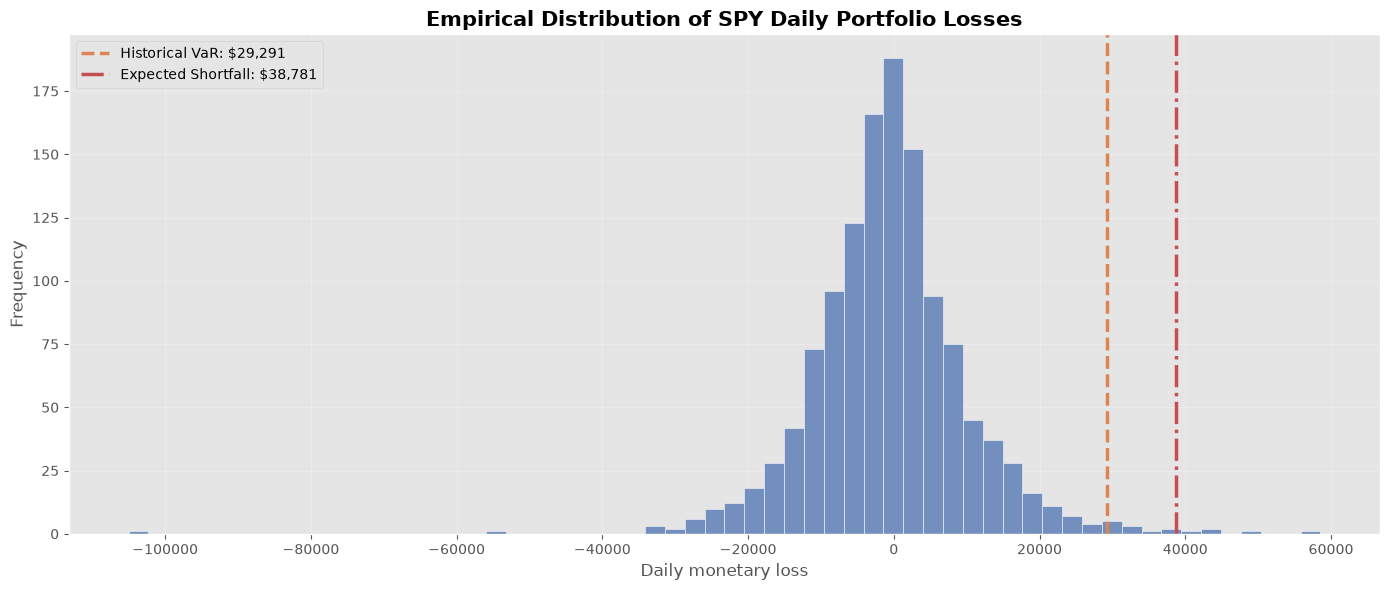

In [9]:
figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.hist(
    historical_losses,
    bins=60,
    color="#4C72B0",
    alpha=0.75,
    edgecolor="white",
)

axis.axvline(
    historical_var,
    color="#DD8452",
    linewidth=2.5,
    linestyle="--",
    label=(
        f"Historical VaR: "
        f"${historical_var:,.0f}"
    ),
)

axis.axvline(
    historical_expected_shortfall,
    color="#C44E52",
    linewidth=2.5,
    linestyle="-.",
    label=(
        f"Expected Shortfall: "
        f"${historical_expected_shortfall:,.0f}"
    ),
)

axis.set_title(
    "Empirical Distribution of SPY Daily Portfolio Losses",
    fontsize=15,
    fontweight="bold",
)

axis.set_xlabel("Daily monetary loss")
axis.set_ylabel("Frequency")
axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 4. Parametric Normal Value at Risk

### 4.1 Distributional assumption

The parametric model assumes that daily returns follow a normal
distribution:

$$
R_t \sim \mathcal{N}(\mu,\sigma^2)
$$

where:

- \(\mu\) is the expected daily return;
- \(\sigma\) is the daily volatility;
- \(\sigma^2\) is the variance.

Because monetary loss is defined as:

$$
L_t = -V R_t
$$

the portfolio-loss distribution is also normal:

$$
L_t
\sim
\mathcal{N}
\left(
-V\mu,
V^2\sigma^2
\right)
$$

Therefore, the mean and standard deviation of monetary losses are:

$$
\mu_L = -V\mu
$$

$$
\sigma_L = V\sigma
$$

### 4.2 Standard normal quantile

Let \(Z\) be a standard normal random variable:

$$
Z \sim \mathcal{N}(0,1)
$$

The critical value \(z_{\alpha}\) satisfies:

$$
P(Z \leq z_{\alpha}) = \alpha
$$

For a 99% confidence level:

$$
z_{0.99} \approx 2.3263
$$

This means that 99% of a standard normal distribution lies below
approximately 2.3263 standard deviations.

### 4.3 Parametric VaR formula

The normal parametric VaR is:

$$
\operatorname{VaR}_{\alpha}^{\text{normal}}
=
\mu_L + \sigma_L z_{\alpha}
$$

Substituting the portfolio-loss mean and volatility:

$$
\operatorname{VaR}_{\alpha}^{\text{normal}}
=
-V\mu + V\sigma z_{\alpha}
$$

Therefore:

$$
\boxed{
\operatorname{VaR}_{\alpha}^{\text{normal}}
=
V
\left(
\sigma z_{\alpha}-\mu
\right)
}
$$

### 4.4 Parametric Expected Shortfall

Let \(\phi(z)\) represent the standard normal probability density
function:

$$
\phi(z)
=
\frac{1}{\sqrt{2\pi}}
\exp
\left(
-\frac{z^2}{2}
\right)
$$

For normally distributed losses, Expected Shortfall is:

$$
\operatorname{ES}_{\alpha}^{\text{normal}}
=
\mu_L
+
\sigma_L
\frac{
\phi(z_{\alpha})
}{
1-\alpha
}
$$

Substituting \(\mu_L=-V\mu\) and \(\sigma_L=V\sigma\):

$$
\boxed{
\operatorname{ES}_{\alpha}^{\text{normal}}
=
V
\left[
-\mu
+
\sigma
\frac{
\phi(z_{\alpha})
}{
1-\alpha
}
\right]
}
$$

### 4.5 Assumptions and limitations

The normal parametric model assumes:

- returns are approximately normally distributed;
- the estimated mean and volatility represent future conditions;
- observations are sufficiently stable through time;
- extreme losses behave according to the normal distribution.

Its main advantage is that it produces an analytical result without
requiring simulations or an empirical quantile calculation.

Its principal weakness is the normality assumption. Financial returns
often exhibit:

- negative skewness;
- fat tails;
- volatility clustering;
- sudden structural changes.

Consequently, a normal model may underestimate the frequency and
severity of extreme market losses.

In [10]:
from scipy.stats import norm

estimated_mean = float(
    returns.mean()
)

estimated_volatility = float(
    returns.std(ddof=1)
)

normal_quantile = float(
    norm.ppf(confidence_level)
)

normal_density = float(
    norm.pdf(normal_quantile)
)

parametric_var = portfolio_value * (
    estimated_volatility * normal_quantile
    - estimated_mean
)

parametric_expected_shortfall = (
    portfolio_value
    * (
        -estimated_mean
        + estimated_volatility
        * normal_density
        / (1.0 - confidence_level)
    )
)

parametric_results = pd.DataFrame(
    {
        "Metric": [
            "Estimated daily mean",
            "Estimated daily volatility",
            "Normal critical value",
            "Parametric VaR",
            "Parametric Expected Shortfall",
        ],
        "Value": [
            f"{estimated_mean:.6%}",
            f"{estimated_volatility:.6%}",
            f"{normal_quantile:.6f}",
            f"${parametric_var:,.2f}",
            f"${parametric_expected_shortfall:,.2f}",
        ],
    }
)

parametric_results

,Metric,Value
0,Estimated daily mean,0.060315%
1,Estimated daily volatility,1.077893%
2,Normal critical value,2.326348
3,Parametric VaR,"$24,472.39"
4,Parametric Expected Shortfall,"$28,125.01"


In [11]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Historical",
            "Parametric normal",
        ],
        "Value at Risk": [
            historical_var,
            parametric_var,
        ],
        "Expected Shortfall": [
            historical_expected_shortfall,
            parametric_expected_shortfall,
        ],
    }
)

formatted_comparison = model_comparison.copy()

formatted_comparison["Value at Risk"] = (
    formatted_comparison["Value at Risk"]
    .map(lambda value: f"${value:,.2f}")
)

formatted_comparison["Expected Shortfall"] = (
    formatted_comparison["Expected Shortfall"]
    .map(lambda value: f"${value:,.2f}")
)

formatted_comparison

,Model,Value at Risk,Expected Shortfall
0,Historical,"$29,290.76","$38,780.64"
1,Parametric normal,"$24,472.39","$28,125.01"


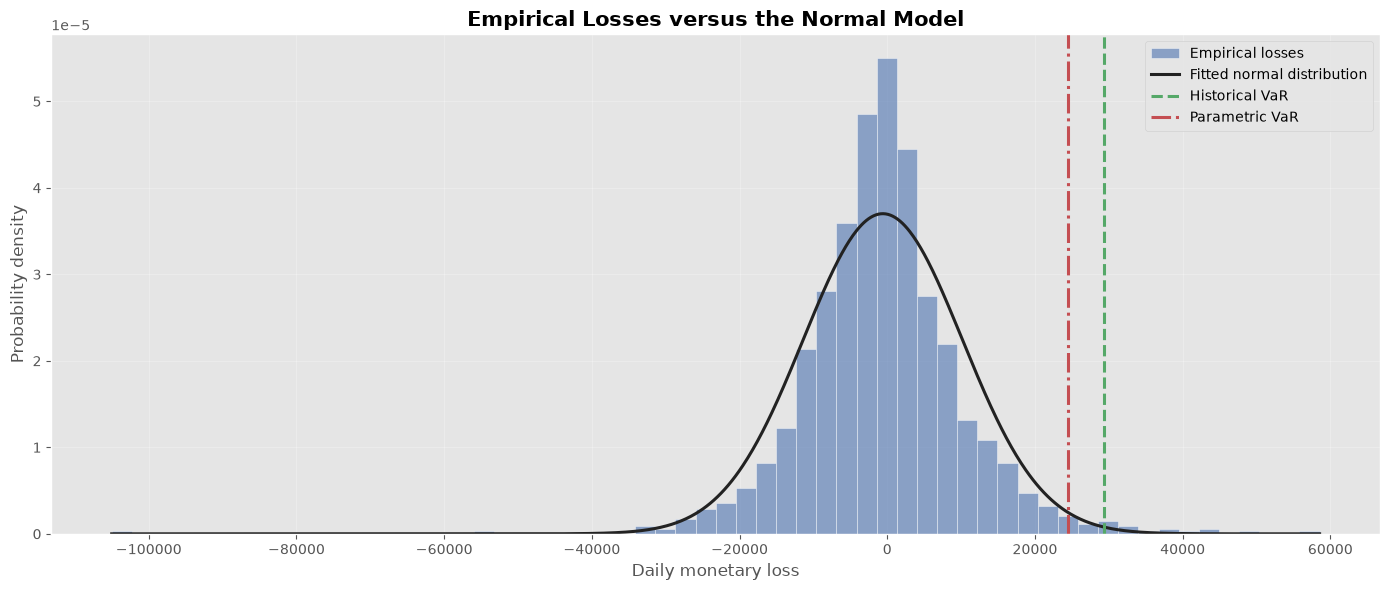

In [12]:
loss_mean = float(
    np.mean(historical_losses)
)

loss_volatility = float(
    np.std(historical_losses, ddof=1)
)

loss_grid = np.linspace(
    historical_losses.min(),
    historical_losses.max(),
    1_000,
)

normal_curve = norm.pdf(
    loss_grid,
    loc=loss_mean,
    scale=loss_volatility,
)

figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.hist(
    historical_losses,
    bins=60,
    density=True,
    color="#4C72B0",
    alpha=0.60,
    edgecolor="white",
    label="Empirical losses",
)

axis.plot(
    loss_grid,
    normal_curve,
    color="#222222",
    linewidth=2.2,
    label="Fitted normal distribution",
)

axis.axvline(
    historical_var,
    color="#55A868",
    linewidth=2.2,
    linestyle="--",
    label="Historical VaR",
)

axis.axvline(
    parametric_var,
    color="#C44E52",
    linewidth=2.2,
    linestyle="-.",
    label="Parametric VaR",
)

axis.set_title(
    "Empirical Losses versus the Normal Model",
    fontsize=15,
    fontweight="bold",
)

axis.set_xlabel("Daily monetary loss")
axis.set_ylabel("Probability density")
axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 5. Monte Carlo Value at Risk

### 5.1 Objective

Monte Carlo VaR estimates portfolio risk by generating a large number of
possible future returns.

Unlike historical VaR, which directly reuses observed losses, Monte
Carlo simulation creates synthetic scenarios from an estimated
probability model.

This risk simulation is performed under the **real-world probability
measure**, using the estimated historical mean and volatility.

It is different from risk-neutral Monte Carlo used for option pricing,
where expected returns are based on the risk-free rate.

### 5.2 Return model

Daily returns are modeled as:

$$
R_i^{(s)}
=
\hat{\mu}
+
\hat{\sigma}Z_i
$$

where:

- \(R_i^{(s)}\) is simulated return \(i\);
- \(\hat{\mu}\) is the estimated historical mean;
- \(\hat{\sigma}\) is the estimated historical volatility;
- \(Z_i\) is a standard normal random variable.

The random shock satisfies:

$$
Z_i \sim \mathcal{N}(0,1)
$$

Each simulated return is converted into a monetary loss:

$$
L_i^{(s)}
=
-V R_i^{(s)}
$$

### 5.3 Monte Carlo VaR

After generating \(N\) simulated losses, Monte Carlo VaR is their
empirical \(\alpha\)-quantile:

$$
\operatorname{VaR}_{\alpha}^{\text{MC}}
=
Q_{\alpha}
\left(
L_1^{(s)},
L_2^{(s)},\ldots,L_N^{(s)}
\right)
$$

### 5.4 Monte Carlo Expected Shortfall

Expected Shortfall is calculated from the simulated losses exceeding the
Monte Carlo VaR:

$$
\operatorname{ES}_{\alpha}^{\text{MC}}
=
E
\left[
L^{(s)}
\mid
L^{(s)}
>
\operatorname{VaR}_{\alpha}^{\text{MC}}
\right]
$$

### 5.5 Antithetic variates

This implementation uses antithetic random shocks.

For each random shock \(Z_i\), the simulation also includes its opposite:

$$
-Z_i
$$

The shock collection is therefore:

$$
Z_1,-Z_1,Z_2,-Z_2,\ldots
$$

Because every positive shock is paired with a negative shock, the
simulated shock mean is close to zero:

$$
\frac{1}{N}
\sum_{i=1}^{N} Z_i
\approx 0
$$

This variance-reduction technique improves stability without requiring
additional independent random-number generation.

### 5.6 Reproducibility

A fixed random seed allows the same pseudo-random scenarios to be
generated again:

$$
\text{seed}=42
$$

Reproducibility is essential for testing, auditing and comparing
quantitative models.

### 5.7 Limitations

This implementation assumes normally distributed returns. Therefore, it
may inherit the same tail limitations as normal parametric VaR.

Monte Carlo becomes more powerful when the simulation includes:

- non-normal innovations;
- stochastic volatility;
- correlated risk factors;
- jumps;
- nonlinear instruments;
- changing market regimes.

In [13]:
number_of_simulations = 500_000
random_seed = 42

if number_of_simulations % 2 != 0:
    raise ValueError(
        "The number of simulations must be even."
    )

random_generator = np.random.default_rng(
    seed=random_seed
)

half_simulations = number_of_simulations // 2

base_shocks = random_generator.standard_normal(
    half_simulations
)

antithetic_shocks = np.concatenate(
    [
        base_shocks,
        -base_shocks,
    ]
)

simulated_returns = (
    estimated_mean
    + estimated_volatility
    * antithetic_shocks
)

simulated_losses = (
    -portfolio_value
    * simulated_returns
)

monte_carlo_var = float(
    np.quantile(
        simulated_losses,
        confidence_level,
    )
)

monte_carlo_tail_losses = simulated_losses[
    simulated_losses > monte_carlo_var
]

monte_carlo_expected_shortfall = float(
    np.mean(monte_carlo_tail_losses)
)

print(
    f"Simulations: "
    f"{number_of_simulations:,}"
)
print(
    f"Mean simulated shock: "
    f"{antithetic_shocks.mean():.12f}"
)
print(
    f"Mean simulated return: "
    f"{simulated_returns.mean():.6%}"
)
print(
    f"Monte Carlo VaR: "
    f"${monte_carlo_var:,.2f}"
)
print(
    f"Monte Carlo Expected Shortfall: "
    f"${monte_carlo_expected_shortfall:,.2f}"
)

Simulations: 500,000
Mean simulated shock: 0.000000000000
Mean simulated return: 0.060315%
Monte Carlo VaR: $24,541.75
Monte Carlo Expected Shortfall: $28,221.78


In [14]:
three_model_comparison = pd.DataFrame(
    {
        "Model": [
            "Historical",
            "Parametric normal",
            "Monte Carlo normal",
        ],
        "Value at Risk": [
            historical_var,
            parametric_var,
            monte_carlo_var,
        ],
        "Expected Shortfall": [
            historical_expected_shortfall,
            parametric_expected_shortfall,
            monte_carlo_expected_shortfall,
        ],
    }
)

three_model_comparison["ES minus VaR"] = (
    three_model_comparison["Expected Shortfall"]
    - three_model_comparison["Value at Risk"]
)

three_model_comparison.style.format(
    {
        "Value at Risk": "${:,.2f}",
        "Expected Shortfall": "${:,.2f}",
        "ES minus VaR": "${:,.2f}",
    }
)

,Model,Value at Risk,Expected Shortfall,ES minus VaR
0,Historical,"$29,290.76","$38,780.64","$9,489.88"
1,Parametric normal,"$24,472.39","$28,125.01","$3,652.62"
2,Monte Carlo normal,"$24,541.75","$28,221.78","$3,680.03"


### 5.8 Interpretation of the comparison

The parametric and Monte Carlo estimates should be relatively close
because both use the same normal return model and the same estimated
parameters.

Their computational approaches are different:

- parametric VaR uses a closed-form mathematical formula;
- Monte Carlo VaR approximates the loss distribution through simulation.

As the number of simulations increases, the Monte Carlo estimate should
converge toward the corresponding parametric result:

$$
\operatorname{VaR}_{\alpha}^{\text{MC}}
\longrightarrow
\operatorname{VaR}_{\alpha}^{\text{normal}}
\quad
\text{as }
N\longrightarrow\infty
$$

Small differences remain because Monte Carlo estimates contain sampling
error.

Historical VaR may differ more substantially because it uses the
empirical loss distribution rather than imposing a normal model.

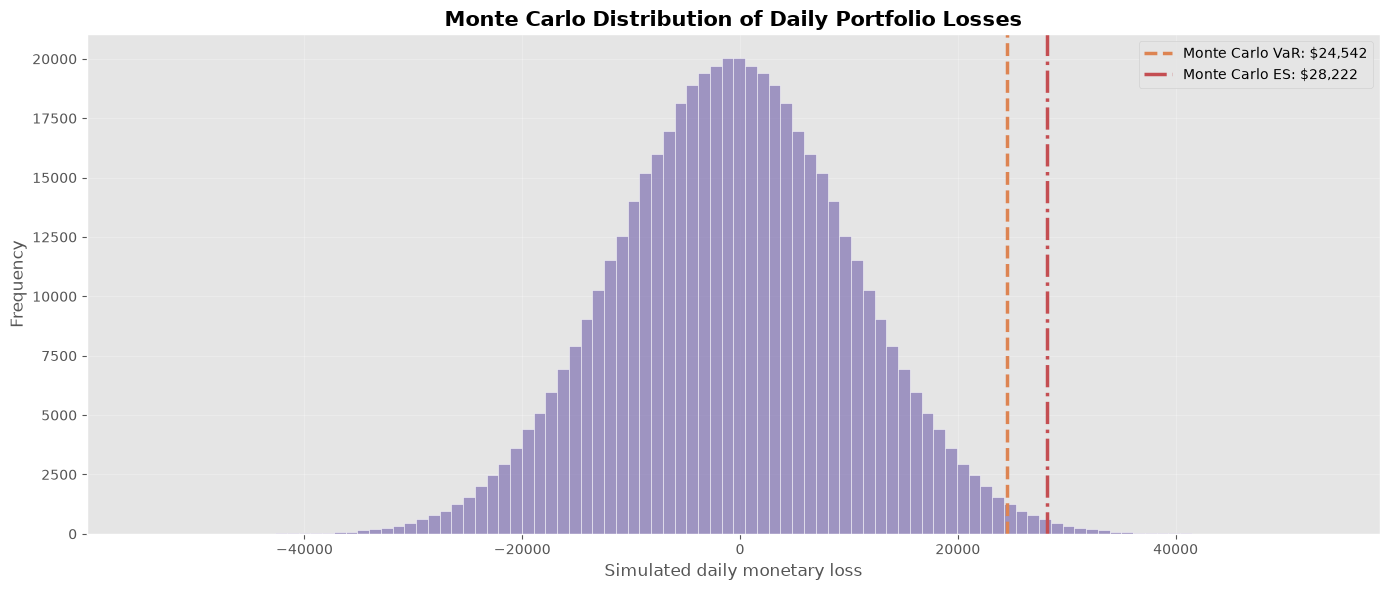

In [15]:
figure, axis = plt.subplots(
    figsize=(14, 6)
)

axis.hist(
    simulated_losses,
    bins=100,
    color="#8172B2",
    alpha=0.70,
    edgecolor="white",
)

axis.axvline(
    monte_carlo_var,
    color="#DD8452",
    linewidth=2.5,
    linestyle="--",
    label=(
        f"Monte Carlo VaR: "
        f"${monte_carlo_var:,.0f}"
    ),
)

axis.axvline(
    monte_carlo_expected_shortfall,
    color="#C44E52",
    linewidth=2.5,
    linestyle="-.",
    label=(
        f"Monte Carlo ES: "
        f"${monte_carlo_expected_shortfall:,.0f}"
    ),
)

axis.set_title(
    "Monte Carlo Distribution of Daily Portfolio Losses",
    fontsize=15,
    fontweight="bold",
)

axis.set_xlabel("Simulated daily monetary loss")
axis.set_ylabel("Frequency")
axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 6. Rolling Value at Risk Forecasts

### 6.1 Motivation

A single VaR estimate assumes that market risk remains constant.
Financial volatility, however, changes through time.

A rolling model repeatedly estimates risk using a moving historical
window.

Let \(w\) denote the window size. To forecast the risk for day \(t\), the
model uses only the preceding returns:

$$
\mathcal{W}_t
=
\left\{
R_{t-w},R_{t-w+1},\ldots,R_{t-1}
\right\}
$$

For a 250-day window:

$$
w=250
$$

This represents approximately one trading year.

### 6.2 Historical rolling VaR

The historical forecast for day \(t\) is:

$$
\operatorname{VaR}_{\alpha,t}^{\text{hist}}
=
Q_{\alpha}
\left(
-VR_{t-w},
\ldots,
-VR_{t-1}
\right)
$$

After the forecast is produced, it is compared with the realized loss:

$$
L_t=-VR_t
$$

The return \(R_t\) is not included in the estimation window. This
ensures that the model does not use future information.

### 6.3 Parametric rolling VaR

For each window, the model estimates:

$$
\hat{\mu}_t
=
\frac{1}{w}
\sum_{i=t-w}^{t-1}R_i
$$

and:

$$
\hat{\sigma}_t
=
\sqrt{
\frac{1}{w-1}
\sum_{i=t-w}^{t-1}
\left(
R_i-\hat{\mu}_t
\right)^2
}
$$

The parametric forecast is then:

$$
\operatorname{VaR}_{\alpha,t}^{\text{normal}}
=
V
\left(
z_{\alpha}\hat{\sigma}_t
-
\hat{\mu}_t
\right)
$$

### 6.4 Expanding through time

After forecasting day \(t\), the window advances one position:

$$
\mathcal{W}_{t+1}
=
\left\{
R_{t-w+1},
\ldots,
R_t
\right\}
$$

The oldest observation is removed and the newest realized return is
included.

This produces a sequence of out-of-sample forecasts:

$$
\operatorname{VaR}_{\alpha,w+1},
\operatorname{VaR}_{\alpha,w+2},
\ldots,
\operatorname{VaR}_{\alpha,n}
$$

Rolling estimation allows VaR to respond to changing market conditions,
although the response may be delayed because all observations inside
the window receive equal weight.

In [16]:
window_size = 250

rolling_forecasts = (
    calculate_rolling_var_forecasts(
        returns=returns.to_numpy(dtype=float),
        portfolio_value=portfolio_value,
        window_size=window_size,
        confidence_level=confidence_level,
    )
)

forecast_dates = returns.index[
    window_size:
]

rolling_summary = pd.DataFrame(
    {
        "Metric": [
            "Estimation window",
            "Out-of-sample observations",
            "Average historical VaR",
            "Minimum historical VaR",
            "Maximum historical VaR",
            "Average parametric VaR",
            "Minimum parametric VaR",
            "Maximum parametric VaR",
        ],
        "Value": [
            f"{window_size} trading days",
            f"{len(rolling_forecasts.actual_losses):,}",
            (
                f"${rolling_forecasts.historical_var.mean():,.2f}"
            ),
            (
                f"${rolling_forecasts.historical_var.min():,.2f}"
            ),
            (
                f"${rolling_forecasts.historical_var.max():,.2f}"
            ),
            (
                f"${rolling_forecasts.parametric_var.mean():,.2f}"
            ),
            (
                f"${rolling_forecasts.parametric_var.min():,.2f}"
            ),
            (
                f"${rolling_forecasts.parametric_var.max():,.2f}"
            ),
        ],
    }
)

rolling_summary

,Metric,Value
0,Estimation window,250 trading days
1,Out-of-sample observations,"1,004"
2,Average historical VaR,"$27,690.74"
3,Minimum historical VaR,"$14,525.19"
4,Maximum historical VaR,"$37,471.99"
5,Average parametric VaR,"$24,653.76"
6,Minimum parametric VaR,"$15,264.67"
7,Maximum parametric VaR,"$36,313.26"


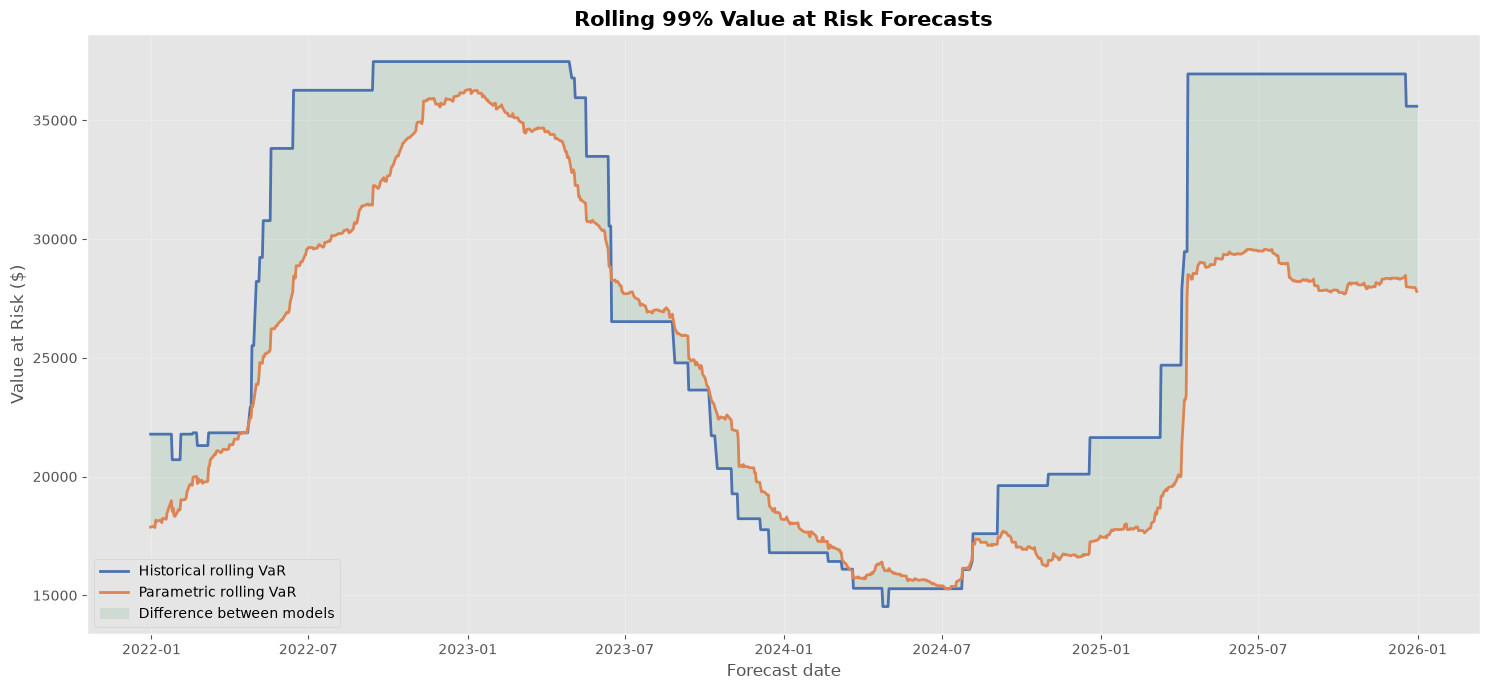

In [17]:
figure, axis = plt.subplots(
    figsize=(15, 7)
)

axis.plot(
    forecast_dates,
    rolling_forecasts.historical_var,
    color="#4C72B0",
    linewidth=2.0,
    label="Historical rolling VaR",
)

axis.plot(
    forecast_dates,
    rolling_forecasts.parametric_var,
    color="#DD8452",
    linewidth=2.0,
    label="Parametric rolling VaR",
)

axis.fill_between(
    forecast_dates,
    rolling_forecasts.historical_var,
    rolling_forecasts.parametric_var,
    color="#55A868",
    alpha=0.15,
    label="Difference between models",
)

axis.set_title(
    "Rolling 99% Value at Risk Forecasts",
    fontsize=15,
    fontweight="bold",
)

axis.set_xlabel("Forecast date")
axis.set_ylabel("Value at Risk ($)")
axis.legend()
axis.grid(alpha=0.25)

figure.tight_layout()
plt.show()

## 7. VaR Exceptions and Unconditional Coverage

### 7.1 Exception indicator

A VaR exception occurs when the realized loss is greater than the VaR
forecast:

$$
L_t >
\operatorname{VaR}_{\alpha,t}
$$

Define the exception indicator:

$$
I_t
=
\mathbf{1}
\left(
L_t >
\operatorname{VaR}_{\alpha,t}
\right)
$$

Equivalently:

$$
I_t
=
\begin{cases}
1, &
\text{if }
L_t >
\operatorname{VaR}_{\alpha,t},\\
0, &
\text{otherwise}.
\end{cases}
$$

The total number of exceptions is:

$$
X
=
\sum_{t=1}^{n} I_t
$$

The observed exception rate is:

$$
\hat{p}
=
\frac{X}{n}
$$

If the VaR confidence level is \(\alpha\), the theoretical exception
probability is:

$$
p=1-\alpha
$$

For 99% VaR:

$$
p=1-0.99=0.01
$$

Therefore, approximately 1% of observations should exceed the VaR.

The expected number of exceptions is:

$$
E[X]
=
n(1-\alpha)
$$

### 7.2 Kupiec unconditional coverage test

The Kupiec test evaluates whether the observed exception frequency is
consistent with the theoretical probability \(p=1-\alpha\).

The hypotheses are:

$$
H_0:\hat{p}=p
$$

$$
H_1:\hat{p}\neq p
$$

Under the null hypothesis, the likelihood is:

$$
\mathcal{L}_0
=
(1-p)^{n-X}p^X
$$

Under the alternative hypothesis, the observed exception probability is
used:

$$
\mathcal{L}_1
=
(1-\hat{p})^{n-X}\hat{p}^{X}
$$

The likelihood-ratio statistic is:

$$
LR_{\mathrm{uc}}
=
-2
\ln
\left(
\frac{\mathcal{L}_0}{\mathcal{L}_1}
\right)
$$

Equivalently:

$$
LR_{\mathrm{uc}}
=
-2
\ln
\left[
\frac{
(1-p)^{n-X}p^X
}{
(1-\hat{p})^{n-X}\hat{p}^{X}
}
\right]
$$

Under the null hypothesis:

$$
LR_{\mathrm{uc}}
\sim
\chi^2(1)
$$

At a 5% significance level, the model is rejected when:

$$
p\text{-value}<0.05
$$

Rejection may occur because the model produces too many exceptions or
too few exceptions. Both outcomes indicate incorrect unconditional
coverage.

In [18]:
historical_backtest = backtest_value_at_risk(
    actual_losses=rolling_forecasts.actual_losses,
    var_forecasts=rolling_forecasts.historical_var,
    confidence_level=confidence_level,
    significance_level=0.05,
)

parametric_backtest = backtest_value_at_risk(
    actual_losses=rolling_forecasts.actual_losses,
    var_forecasts=rolling_forecasts.parametric_var,
    confidence_level=confidence_level,
    significance_level=0.05,
)

kupiec_comparison = pd.DataFrame(
    {
        "Model": [
            "Historical rolling VaR",
            "Parametric rolling VaR",
        ],
        "Observations": [
            historical_backtest.observations,
            parametric_backtest.observations,
        ],
        "Expected exceptions": [
            historical_backtest.expected_exceptions,
            parametric_backtest.expected_exceptions,
        ],
        "Actual exceptions": [
            historical_backtest.actual_exceptions,
            parametric_backtest.actual_exceptions,
        ],
        "Exception rate": [
            historical_backtest.exception_rate,
            parametric_backtest.exception_rate,
        ],
        "Kupiec statistic": [
            historical_backtest.kupiec_test.likelihood_ratio,
            parametric_backtest.kupiec_test.likelihood_ratio,
        ],
        "Kupiec p-value": [
            historical_backtest.kupiec_test.p_value,
            parametric_backtest.kupiec_test.p_value,
        ],
        "Rejected": [
            historical_backtest.kupiec_test.rejected,
            parametric_backtest.kupiec_test.rejected,
        ],
    }
)

kupiec_comparison.style.format(
    {
        "Expected exceptions": "{:.2f}",
        "Exception rate": "{:.2%}",
        "Kupiec statistic": "{:.6f}",
        "Kupiec p-value": "{:.6f}",
    }
)

,Model,Observations,Expected exceptions,Actual exceptions,Exception rate,Kupiec statistic,Kupiec p-value,Rejected
0,Historical rolling VaR,1004,10.04,20,1.99%,7.746346,0.005382,True
1,Parametric rolling VaR,1004,10.04,28,2.79%,21.841628,0.000003,True


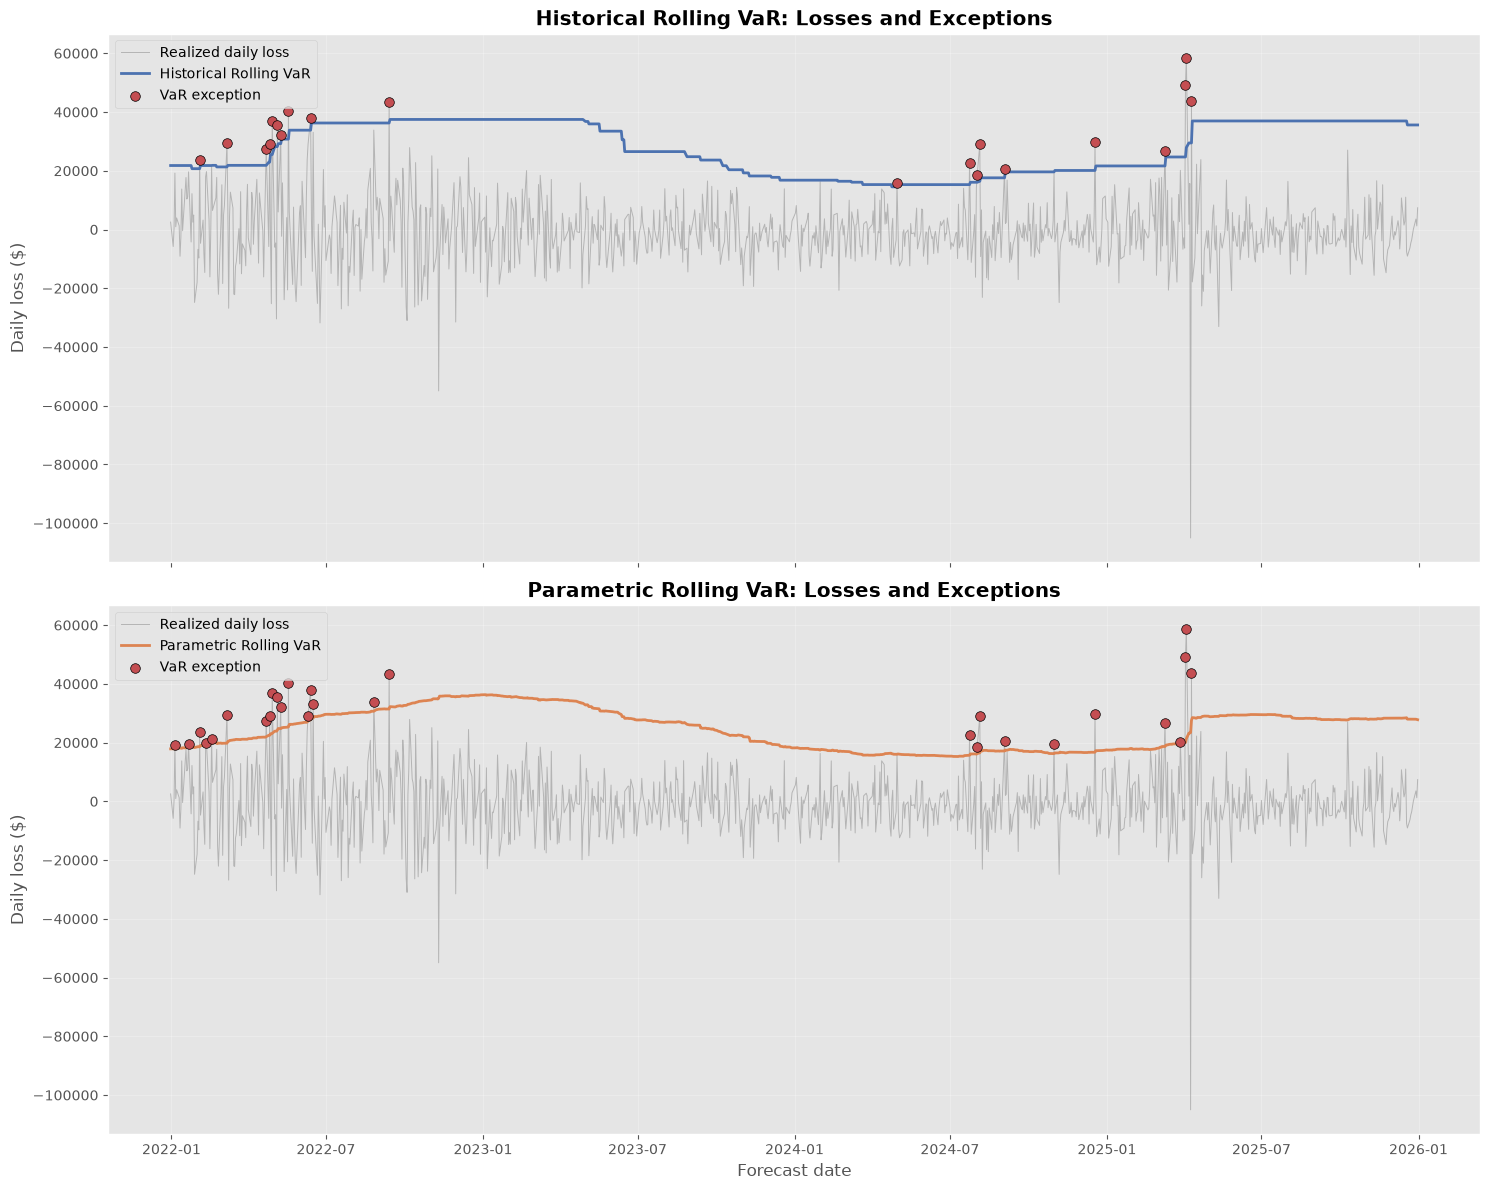

In [19]:
figure, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 12),
    sharex=True,
)

models = [
    (
        axes[0],
        rolling_forecasts.historical_var,
        historical_backtest.exceptions,
        "Historical Rolling VaR",
        "#4C72B0",
    ),
    (
        axes[1],
        rolling_forecasts.parametric_var,
        parametric_backtest.exceptions,
        "Parametric Rolling VaR",
        "#DD8452",
    ),
]

for (
    axis,
    var_series,
    exceptions,
    title,
    color,
) in models:
    axis.plot(
        forecast_dates,
        rolling_forecasts.actual_losses,
        color="#9A9A9A",
        linewidth=0.7,
        alpha=0.65,
        label="Realized daily loss",
    )

    axis.plot(
        forecast_dates,
        var_series,
        color=color,
        linewidth=2.0,
        label=title,
    )

    axis.scatter(
        forecast_dates[exceptions],
        rolling_forecasts.actual_losses[
            exceptions
        ],
        color="#C44E52",
        edgecolor="black",
        linewidth=0.5,
        s=48,
        zorder=5,
        label="VaR exception",
    )

    axis.set_title(
        f"{title}: Losses and Exceptions",
        fontweight="bold",
    )
    axis.set_ylabel("Daily loss ($)")
    axis.legend(loc="upper left")
    axis.grid(alpha=0.25)

axes[1].set_xlabel("Forecast date")

figure.tight_layout()
plt.show()

## 8. Christoffersen Independence Test

### 8.1 Why exception independence matters

The Kupiec test evaluates the total number of VaR exceptions, but it does
not examine when those exceptions occur.

A model could produce approximately the correct total number of
exceptions while allowing several of them to appear consecutively during
a market crisis.

A reliable VaR model should satisfy two conditions:

1. The exception frequency should be correct.
2. Exceptions should occur independently through time.

If exceptions cluster together, the model may be reacting too slowly to
changes in market volatility.

### 8.2 Exception transitions

Let \(I_t\) represent the exception indicator:

$$
I_t
=
\begin{cases}
1, & \text{if a VaR exception occurs on day } t,\\
0, & \text{otherwise}.
\end{cases}
$$

Christoffersen analyzes transitions between consecutive observations:

$$
(I_{t-1},I_t)
$$

There are four possible transitions:

| Transition | Meaning |
|---|---|
| \(0 \rightarrow 0\) | No exception followed by no exception |
| \(0 \rightarrow 1\) | No exception followed by an exception |
| \(1 \rightarrow 0\) | Exception followed by no exception |
| \(1 \rightarrow 1\) | Exception followed by another exception |

Let \(n_{ij}\) denote the number of transitions from state \(i\) to
state \(j\).

The transition-count matrix is:

$$
N
=
\begin{pmatrix}
n_{00} & n_{01}\\
n_{10} & n_{11}
\end{pmatrix}
$$

### 8.3 Conditional exception probabilities

The probability of an exception after a normal day is estimated by:

$$
\hat{\pi}_{01}
=
\frac{n_{01}}{n_{00}+n_{01}}
$$

The probability of an exception after another exception is:

$$
\hat{\pi}_{11}
=
\frac{n_{11}}{n_{10}+n_{11}}
$$

If exceptions are independent, the previous day's state should not
change the probability of an exception:

$$
\hat{\pi}_{01}
\approx
\hat{\pi}_{11}
$$

A substantially larger value of \(\hat{\pi}_{11}\) indicates exception
clustering.

### 8.4 Independence hypothesis

The hypotheses are:

$$
H_0:
\pi_{01}=\pi_{11}
$$

$$
H_1:
\pi_{01}\neq\pi_{11}
$$

Under independence, the pooled exception probability is:

$$
\hat{\pi}
=
\frac{
n_{01}+n_{11}
}{
n_{00}+n_{01}+n_{10}+n_{11}
}
$$

The likelihood under independence is:

$$
\mathcal{L}_0
=
(1-\hat{\pi})^{n_{00}+n_{10}}
\hat{\pi}^{n_{01}+n_{11}}
$$

The first-order Markov likelihood under dependence is:

$$
\mathcal{L}_1
=
(1-\hat{\pi}_{01})^{n_{00}}
\hat{\pi}_{01}^{n_{01}}
(1-\hat{\pi}_{11})^{n_{10}}
\hat{\pi}_{11}^{n_{11}}
$$

The independence likelihood-ratio statistic is:

$$
LR_{\mathrm{ind}}
=
-2
\ln
\left(
\frac{\mathcal{L}_0}{\mathcal{L}_1}
\right)
$$

Under the null hypothesis:

$$
LR_{\mathrm{ind}}
\sim
\chi^2(1)
$$

At a 5% significance level, independence is rejected when:

$$
p\text{-value}<0.05
$$

## 9. Conditional Coverage Test

A complete VaR model should have both:

- correct unconditional coverage;
- independent exceptions.

The conditional coverage test combines the Kupiec and Christoffersen
statistics:

$$
LR_{\mathrm{cc}}
=
LR_{\mathrm{uc}}
+
LR_{\mathrm{ind}}
$$

where:

- \(LR_{\mathrm{uc}}\) measures whether the exception frequency is
  correct;
- \(LR_{\mathrm{ind}}\) measures whether exceptions are independent.

Because two restrictions are evaluated:

$$
LR_{\mathrm{cc}}
\sim
\chi^2(2)
$$

The hypotheses are:

$$
H_0:
\text{The model has correct coverage and independent exceptions}
$$

$$
H_1:
\text{At least one of these conditions fails}
$$

At a 5% significance level:

$$
p\text{-value}<0.05
\quad\Longrightarrow\quad
\text{reject the VaR model}
$$

Passing the independence test alone is not sufficient. A model can
produce independent exceptions but still generate too many or too few
of them.

In [20]:
historical_conditional = (
    conditional_coverage_test(
        exceptions=historical_backtest.exceptions,
        confidence_level=confidence_level,
        significance_level=0.05,
    )
)

parametric_conditional = (
    conditional_coverage_test(
        exceptions=parametric_backtest.exceptions,
        confidence_level=confidence_level,
        significance_level=0.05,
    )
)

historical_independence = (
    historical_conditional.independence_test
)

parametric_independence = (
    parametric_conditional.independence_test
)

christoffersen_comparison = pd.DataFrame(
    {
        "Model": [
            "Historical rolling VaR",
            "Parametric rolling VaR",
        ],
        "P(exception | no exception)": [
            (
                historical_independence
                .probability_after_no_exception
            ),
            (
                parametric_independence
                .probability_after_no_exception
            ),
        ],
        "P(exception | exception)": [
            (
                historical_independence
                .probability_after_exception
            ),
            (
                parametric_independence
                .probability_after_exception
            ),
        ],
        "Independence statistic": [
            historical_independence.likelihood_ratio,
            parametric_independence.likelihood_ratio,
        ],
        "Independence p-value": [
            historical_independence.p_value,
            parametric_independence.p_value,
        ],
        "Independence rejected": [
            historical_independence.rejected,
            parametric_independence.rejected,
        ],
        "Conditional statistic": [
            historical_conditional.likelihood_ratio,
            parametric_conditional.likelihood_ratio,
        ],
        "Conditional p-value": [
            historical_conditional.p_value,
            parametric_conditional.p_value,
        ],
        "Conditional rejected": [
            historical_conditional.rejected,
            parametric_conditional.rejected,
        ],
    }
)

christoffersen_comparison.style.format(
    {
        "P(exception | no exception)": "{:.2%}",
        "P(exception | exception)": "{:.2%}",
        "Independence statistic": "{:.6f}",
        "Independence p-value": "{:.6f}",
        "Conditional statistic": "{:.6f}",
        "Conditional p-value": "{:.6f}",
    }
)

,Model,P(exception | no exception),P(exception | exception),Independence statistic,Independence p-value,Independence rejected,Conditional statistic,Conditional p-value,Conditional rejected
0,Historical rolling VaR,1.83%,10.00%,3.519029,0.060668,False,11.265375,0.003579,True
1,Parametric rolling VaR,2.56%,10.71%,4.010066,0.045229,True,25.851694,0.000002,True


In [21]:
historical_transitions = (
    historical_independence.transitions
)

parametric_transitions = (
    parametric_independence.transitions
)

transition_comparison = pd.DataFrame(
    {
        "Transition": [
            "0 → 0",
            "0 → 1",
            "1 → 0",
            "1 → 1",
        ],
        "Historical VaR": [
            (
                historical_transitions
                .no_exception_to_no_exception
            ),
            (
                historical_transitions
                .no_exception_to_exception
            ),
            (
                historical_transitions
                .exception_to_no_exception
            ),
            (
                historical_transitions
                .exception_to_exception
            ),
        ],
        "Parametric VaR": [
            (
                parametric_transitions
                .no_exception_to_no_exception
            ),
            (
                parametric_transitions
                .no_exception_to_exception
            ),
            (
                parametric_transitions
                .exception_to_no_exception
            ),
            (
                parametric_transitions
                .exception_to_exception
            ),
        ],
    }
)

transition_comparison

,Transition,Historical VaR,Parametric VaR
0,0 → 0,965,950
1,0 → 1,18,25
2,1 → 0,18,25
3,1 → 1,2,3


## 10. Backtesting Interpretation

The historical model produced fewer exceptions than the parametric
normal model and therefore performed better in relative terms.

However, the Kupiec test rejected both models because each produced more
exceptions than expected at the 99% confidence level.

For the historical model, the Christoffersen independence test was not
rejected at the 5% significance level. This indicates insufficient
statistical evidence of exception clustering.

Nevertheless, its conditional coverage test was rejected because its
exception frequency was incorrect.

The parametric model was rejected by:

- the Kupiec unconditional coverage test;
- the Christoffersen independence test;
- the combined conditional coverage test.

This indicates that the parametric model produced too many exceptions
and that those exceptions exhibited evidence of temporal dependence.

The empirical results therefore illustrate two important weaknesses of
the normal model:

1. Financial losses may occur more frequently in the tail than predicted
   by the normal distribution.
2. Extreme losses may cluster during periods of elevated volatility.

Among the two rolling models, historical VaR performed better, but
neither model achieved statistically adequate conditional coverage.

## 11. Basel Traffic-Light Framework

### 11.1 Regulatory interpretation

The Basel traffic-light framework classifies a 99% one-day VaR model
using 250 trading-day observations.

If the VaR model is correctly calibrated, the theoretical number of
exceptions follows a binomial distribution:

$$
X
\sim
\operatorname{Binomial}
\left(
n=250,
p=0.01
\right)
$$

The expected number of exceptions is:

$$
E[X]
=
np
=
250(0.01)
=
2.5
$$

The variance is:

$$
\operatorname{Var}(X)
=
np(1-p)
$$

Therefore:

$$
\operatorname{Var}(X)
=
250(0.01)(0.99)
=
2.475
$$

The standard deviation is:

$$
\sigma_X
=
\sqrt{2.475}
\approx
1.573
$$

### 11.2 Traffic-light zones

For a 250-day backtest at 99% confidence, the classification is:

| Zone | Exceptions | Interpretation |
|---|---:|---|
| Green | 0–4 | Model performance is broadly acceptable |
| Yellow | 5–9 | Model requires attention and additional review |
| Red | 10 or more | Strong evidence that the model underestimates risk |

The traffic-light framework focuses principally on excessive exception
counts.

It is possible for a model to be in the green zone while being rejected
by the Kupiec test. For example, zero exceptions may indicate that the
model is excessively conservative, but it does not create the regulatory
concern associated with too many losses exceeding VaR.

Because the complete out-of-sample period contains more than 250
observations, the Basel classification is applied to the most recent 250
forecast days.

In [22]:
basel_window = 250

recent_losses = (
    rolling_forecasts.actual_losses[
        -basel_window:
    ]
)

recent_historical_var = (
    rolling_forecasts.historical_var[
        -basel_window:
    ]
)

recent_parametric_var = (
    rolling_forecasts.parametric_var[
        -basel_window:
    ]
)

historical_basel_backtest = (
    backtest_value_at_risk(
        actual_losses=recent_losses,
        var_forecasts=recent_historical_var,
        confidence_level=confidence_level,
        significance_level=0.05,
    )
)

parametric_basel_backtest = (
    backtest_value_at_risk(
        actual_losses=recent_losses,
        var_forecasts=recent_parametric_var,
        confidence_level=confidence_level,
        significance_level=0.05,
    )
)

basel_comparison = pd.DataFrame(
    {
        "Model": [
            "Historical rolling VaR",
            "Parametric rolling VaR",
        ],
        "Observations": [
            historical_basel_backtest.observations,
            parametric_basel_backtest.observations,
        ],
        "Expected exceptions": [
            (
                historical_basel_backtest
                .expected_exceptions
            ),
            (
                parametric_basel_backtest
                .expected_exceptions
            ),
        ],
        "Actual exceptions": [
            (
                historical_basel_backtest
                .actual_exceptions
            ),
            (
                parametric_basel_backtest
                .actual_exceptions
            ),
        ],
        "Exception rate": [
            (
                historical_basel_backtest
                .exception_rate
            ),
            (
                parametric_basel_backtest
                .exception_rate
            ),
        ],
        "Basel zone": [
            historical_basel_backtest.basel_zone,
            parametric_basel_backtest.basel_zone,
        ],
    }
)

basel_comparison.style.format(
    {
        "Expected exceptions": "{:.2f}",
        "Exception rate": "{:.2%}",
    }
)

,Model,Observations,Expected exceptions,Actual exceptions,Exception rate,Basel zone
0,Historical rolling VaR,250,2.50,4,1.60%,green
1,Parametric rolling VaR,250,2.50,5,2.00%,yellow


## 12. Model Limitations

### 12.1 Historical VaR

Historical VaR preserves the empirical characteristics of observed
returns, but it assumes that the selected historical period represents
future market behavior.

It cannot anticipate an event that has no comparable observation in its
estimation window.

### 12.2 Parametric normal VaR

Normal VaR is computationally efficient and analytically transparent,
but it may underestimate extreme losses when returns exhibit skewness,
fat tails or volatility clustering.

### 12.3 Monte Carlo VaR

Monte Carlo is a flexible computational framework, but its quality
depends entirely on the selected data-generating model.

A large number of simulations cannot correct an unrealistic probability
model.

### 12.4 Rolling estimation

Rolling windows allow risk estimates to vary through time, but equal
weighting may create delayed reactions:

- old observations remain influential until they leave the window;
- recent observations receive no more importance than older ones;
- sudden volatility changes may initially be underestimated.

### 12.5 Backtesting limitations

A backtesting result depends on:

- confidence level;
- sample length;
- estimation-window size;
- market regime;
- portfolio composition;
- statistical significance level.

Failure to reject a model does not prove that the model is correct. It
only means that the available evidence was insufficient to reject it.

## 13. Conclusions

This project developed an end-to-end financial risk measurement and
backtesting framework using real SPY market data.

The analysis demonstrated how to:

1. Transform adjusted prices into daily returns.
2. Convert returns into monetary portfolio losses.
3. Estimate historical VaR and Expected Shortfall.
4. Derive normal parametric VaR and Expected Shortfall.
5. Generate Monte Carlo loss scenarios using antithetic variates.
6. Produce rolling out-of-sample VaR forecasts.
7. Identify days when realized losses exceeded forecast VaR.
8. Evaluate exception frequency using the Kupiec test.
9. Evaluate exception independence using the Christoffersen test.
10. Combine both properties through conditional coverage.
11. Apply the Basel traffic-light framework.

The empirical backtest showed that the historical model performed better
than the parametric normal model in relative terms.

Nevertheless, neither rolling model achieved adequate conditional
coverage over the complete evaluation period.

The results emphasize an essential principle of quantitative risk
management:

> A risk model must not only produce estimates; it must also be tested
> against realized market outcomes.

Possible future extensions include:

- exponentially weighted volatility;
- GARCH volatility models;
- Student-\(t\) innovations;
- filtered historical simulation;
- multivariate portfolio risk;
- stress testing;
- expected-shortfall backtesting;
- regulatory capital calculations.